In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
from torch_geometric.data import HeteroData

root = Path().resolve()
if not (root / "src").exists():
    root = root.parent

sys.path.append(str(root))

from src.data.generators import generate_uncap_instance
from src.data.data import UncapGeneratorConfig, NormalConfig, UniformConfig
from src.data.prepare_data import GenerateDataset
from src.traces.uncap import solve_uncap_jv
from src.solvers.uncap_exact import solve_uncap_exact, solve_dual_exact
from src.utils.collate_fn import collate_fn

/home/simon/repos/FLP-NAR/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gen_config = UncapGeneratorConfig(
    n_fac=10,
    n_cli=10,
    seed=33,
    demand_config=UniformConfig(0,1), #"normalized"
    facility_cost_config=UniformConfig(0,1), #"normalized"
    coords_config=NormalConfig(mean=0.5, std=0.5)
)

In [3]:
dataset = GenerateDataset(gen_config, n_samples=1000, cache_dir=Path("data"), res_only=True)
dataset.prepare_data()

loading instances from cache


In [4]:
from torch.utils.data import DataLoader  # Use standard PyTorch DataLoader, not PyG's
import importlib
import src.models.reasoners
importlib.reload(src.models.reasoners)  # Force reload to pick up changes
from src.models.reasoners import Reasoner

# ── DataLoaders ────────────────────────────────────────────────────────────────
train_size = int(0.75 * len(dataset))
val_size   = len(dataset) - train_size
train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

BATCH_SIZE = 512  # Now we can use batch_size > 1

# Use standard DataLoader with our custom collate function
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# ── Model & optimiser ──────────────────────────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = Reasoner(hidden_dim=128, tf_prob=0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f"device : {device}")
print(f"params : {sum(p.numel() for p in model.parameters()):,}")
print(f"train  : {len(train_data)} samples  |  val: {len(val_data)} samples")

/home/simon/repos/FLP-NAR/src/models/processors.py:13: UserWarning: There exist node types ({'x', 'y'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.primal_to_dual = HeteroConv({
/home/simon/repos/FLP-NAR/src/models/processors.py:25: UserWarning: There exist node types ({'alpha', 'beta'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.out = HeteroConv({


device : cuda
params : 199,559
train  : 750 samples  |  val: 250 samples


In [5]:
from dataclasses import dataclass, field
from typing import Callable
from tqdm.auto import tqdm

@dataclass
class LossConfig:
    """Configuration for loss weights with optional scheduling."""
    weights: dict = field(default_factory=lambda: {
        "alpha_loss": 0.0, "beta_loss": 0.0, "x_loss": 0.0,
        "y_loss": 1.0, "delta_loss": 1.0, "x_res_loss": 1.0,
        "y_res_loss": 1.0, "optimum_loss": 0.1, "optimum_diff": 0.0, "dual_diff": 0.0,
    })
    # Optional schedulers: dict[loss_name -> Callable(epoch) -> weight]
    schedulers: dict = field(default_factory=dict)
    
    def get_weights(self, epoch: int) -> dict:
        """Get weights for a given epoch, applying schedulers if defined."""
        w = self.weights.copy()
        for k, scheduler in self.schedulers.items():
            if k in w:
                w[k] = scheduler(epoch)
        return w


class Trainer:
    """Clean training loop with LR and loss weight scheduling."""
    
    def __init__(self, model, optimizer, loss_config: LossConfig, 
                 lr_scheduler=None, device="cuda"):
        self.model = model
        self.optimizer = optimizer
        self.loss_config = loss_config
        self.lr_scheduler = lr_scheduler
        self.device = device
        self.history = {"train": [], "val": []}
    
    def _run_epoch(self, loader, weights: dict, train: bool) -> dict:
        """Run a single epoch."""
        self.model.train(train)
        totals = {k: 0.0 for k in weights}
        n_batches = 0
        
        with torch.set_grad_enabled(train):
            for batch in loader:
                batch = batch.to(self.device)
                losses = self.model.teacher_forcing(batch)
                total = sum(weights[k] * losses[k] for k in weights)
                
                if train:
                    self.optimizer.zero_grad()
                    total.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    self.optimizer.step()
                
                for k in weights:
                    totals[k] += losses[k].item()
                n_batches += 1
        
        return {k: v / n_batches for k, v in totals.items()}
    
    def _format_metrics(self, losses: dict, weights: dict, prefix: str) -> str:
        """Format metrics for display."""
        total = sum(weights[k] * losses[k] for k in weights)
        return (f"{prefix}: {total:.4f} | "
                f"opt_diff: {losses['optimum_diff']:.3f} "
                f"dual_diff: {losses['dual_diff']:.3f} "
                f"x_res: {losses['x_res_loss']:.3f} "
                f"y_res: {losses['y_res_loss']:.3f} "
                f"δ: {losses['delta_loss']:.3f}")
    
    def fit(self, train_loader, val_loader, n_epochs: int, verbose: bool = True):
        """Train for n_epochs with progress display."""
        pbar = tqdm(range(1, n_epochs + 1), desc="Training", disable=not verbose)
        
        for epoch in pbar:
            weights = self.loss_config.get_weights(epoch)
            
            # Training
            train_losses = self._run_epoch(train_loader, weights, train=True)
            self.history["train"].append(train_losses)
            
            # Validation
            val_losses = self._run_epoch(val_loader, weights, train=False)
            self.history["val"].append(val_losses)
            
            # LR scheduling
            if self.lr_scheduler:
                if isinstance(self.lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    val_total = sum(weights[k] * val_losses[k] for k in weights)
                    self.lr_scheduler.step(val_total)
                else:
                    self.lr_scheduler.step()
            
            # Progress display
            if verbose:
                train_str = self._format_metrics(train_losses, weights, "train")
                val_str = self._format_metrics(val_losses, weights, "val")
                lr = self.optimizer.param_groups[0]['lr']
                pbar.set_postfix_str(f"lr={lr:.2e}")
                tqdm.write(f"Epoch {epoch:03d} | {train_str}")
                tqdm.write(f"        | {val_str}")
        
        return self.history


# ── Setup training ─────────────────────────────────────────────────────────────
loss_config = LossConfig(
    weights={
        "alpha_loss": 1.0, "beta_loss": 1.0, "x_loss": 1.0,
        "y_loss": 1.0, "delta_loss": 2.0, "x_res_loss": 2.0,
        "y_res_loss": 2.0, "optimum_loss": 0.0, "optimum_diff": 0.0, "dual_diff": 0.0,
    },
    # Example schedulers: gradually increase optimum_loss weight
    schedulers={
        #"optimum_loss": lambda e: min(0.1 + 0.02 * e, 0.5),  # ramp up over epochs
    }
)

# LR scheduler: reduce on plateau or cosine annealing
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-7)
# Alternative: lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

trainer = Trainer(model, optimizer, loss_config, lr_scheduler, device)

# ── Train ──────────────────────────────────────────────────────────────────────
N_EPOCHS = 50
history = trainer.fit(train_loader, val_loader, N_EPOCHS)

Training:   0%|          | 0/50 [00:00<?, ?it/s]/home/simon/repos/FLP-NAR/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training:   2%|▏         | 1/50 [00:05<04:09,  5.09s/it, lr=9.99e-05]

Epoch 001 | train: 21.2923 | opt_diff: 1.450 dual_diff: 1.049 x_res: 3.593 y_res: 0.779 δ: 1.152
        | val: 6.1491 | opt_diff: 2.866 dual_diff: 2.161 x_res: 0.164 y_res: 0.182 δ: 0.219


Training:   4%|▍         | 2/50 [00:07<03:01,  3.77s/it, lr=9.96e-05]

Epoch 002 | train: 5.4249 | opt_diff: 1.431 dual_diff: 1.046 x_res: 0.342 y_res: 0.263 δ: 0.197
        | val: 3.8270 | opt_diff: 2.486 dual_diff: 1.875 x_res: 0.129 y_res: 0.183 δ: 0.166


Training:   6%|▌         | 3/50 [00:10<02:30,  3.20s/it, lr=9.91e-05]

...

Epoch 048 | train: 1.5195 | opt_diff: 1.459 dual_diff: 1.048 x_res: 0.085 y_res: 0.174 δ: 0.034
        | val: 1.7525 | opt_diff: 2.486 dual_diff: 1.875 x_res: 0.070 y_res: 0.183 δ: 0.095


Training:  98%|█████████▊| 49/50 [02:00<00:02,  2.35s/it, lr=1.99e-07]

Epoch 049 | train: 1.5431 | opt_diff: 1.464 dual_diff: 1.067 x_res: 0.083 y_res: 0.176 δ: 0.039
        | val: 1.7518 | opt_diff: 2.486 dual_diff: 1.875 x_res: 0.070 y_res: 0.183 δ: 0.095


Training: 100%|██████████| 50/50 [02:02<00:00,  2.46s/it, lr=1.00e-07]

Epoch 050 | train: 1.5876 | opt_diff: 1.447 dual_diff: 1.047 x_res: 0.086 y_res: 0.187 δ: 0.051
        | val: 1.7510 | opt_diff: 2.486 dual_diff: 1.875 x_res: 0.070 y_res: 0.183 δ: 0.094


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Multi-size test datasets for scalability evaluation
# ══════════════════════════════════════════════════════════════════════════════
# Note: Each size needs its own dataloader since batching assumes uniform n_cli/n_fac

def create_test_datasets(sizes: list[tuple[int, int]], n_samples: int = 100, base_seed: int = 9999):
    """
    Create test datasets of varying sizes.
    
    Args:
        sizes: List of (n_fac, n_cli) tuples
        n_samples: Number of samples per size
        base_seed: Base seed (offset by size index for reproducibility)
    
    Returns:
        Dict mapping size tuple to (dataset, dataloader)
    """
    test_datasets = {}
    
    for i, (n_fac, n_cli) in enumerate(sizes):
        print(f"Generating test set: n_fac={n_fac}, n_cli={n_cli}...")
        
        config = UncapGeneratorConfig(
            n_fac=n_fac,
            n_cli=n_cli,
            seed=base_seed + i * 1000,
            demand_config=UniformConfig(0, 1),
            facility_cost_config=UniformConfig(0, 1),
            coords_config=NormalConfig(mean=0.5, std=0.5)
        )
        
        dataset = GenerateDataset(
            config, 
            n_samples=n_samples, 
            cache_dir=Path(f"data/test_{n_fac}x{n_cli}"),
            res_only=True
        )
        dataset.prepare_data()
        
        # Batch size 1 for varying sizes, or same-size batching
        loader = DataLoader(
            dataset, 
            batch_size=1,  # Safe default for varying sizes
            shuffle=False, 
            collate_fn=collate_fn
        )
        
        test_datasets[(n_fac, n_cli)] = {"dataset": dataset, "loader": loader}
    
    return test_datasets


# Define test sizes: same as train, smaller, and larger
TEST_SIZES = [
    (5, 5),    # Smaller
    (10, 10),  # Same as training
    (15, 15),  # Larger
    (20, 20),  # Even larger
    (10, 20),  # Asymmetric: more clients
    (20, 10),  # Asymmetric: more facilities
]

# Generate test datasets (this may take a while for larger sizes)
test_datasets = create_test_datasets(TEST_SIZES, n_samples=50)

Generating test set: n_fac=5, n_cli=5...
loading instances from cache
Generating test set: n_fac=10, n_cli=10...
loading instances from cache
Generating test set: n_fac=15, n_cli=15...
loading instances from cache
Generating test set: n_fac=20, n_cli=20...
loading instances from cache
Generating test set: n_fac=10, n_cli=20...
loading instances from cache
Generating test set: n_fac=20, n_cli=10...
loading instances from cache


Evaluating 5x5...
Evaluating 10x10...
Evaluating 15x15...
Evaluating 20x20...
Evaluating 10x20...
Evaluating 20x10...
       opt_ratio_mean  opt_ratio_std  gap_pct_mean  gap_pct_median  \
size                                                                 
10x10          2.3187         0.3471      131.8689        131.9561   
10x20          1.6434         0.1887       64.3368         66.2796   
15x15          2.7271         0.4526      172.7115        163.4516   
20x10          4.8100         0.8935      381.0024        358.9633   
20x20          2.9066         0.5722      190.6566        184.1053   
5x5            1.8787         0.4179       87.8738         87.3383   

       fac_opened_mean  fac_target_mean  count  
size                                            
10x10             10.0             5.90     50  
10x20             10.0             8.60     50  
15x15             15.0             7.86     50  
20x10             20.0             6.14     50  
20x20             18.4     

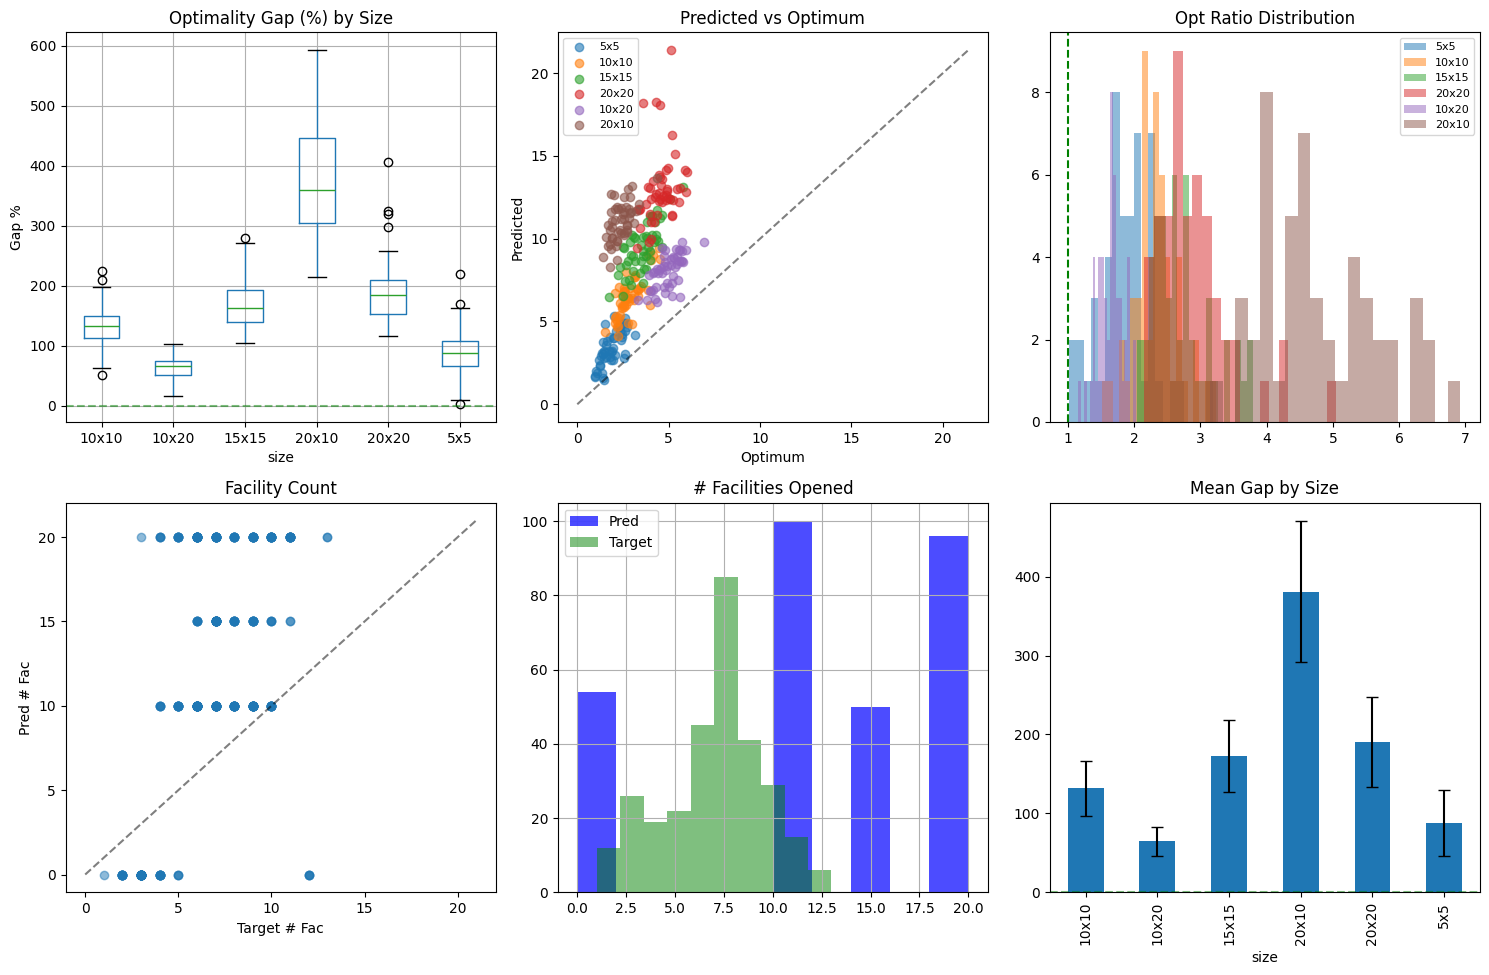

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Evaluation using Reasoner.inference()
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt
import importlib, src.models.reasoners
importlib.reload(src.models.reasoners)
from src.models.reasoners import Reasoner

# ── Collect results across all test sizes ─────────────────────────────────────
all_results = []
for (nf, nc), data in test_datasets.items():
    print(f"Evaluating {nf}x{nc}...")
    for batch in data["loader"]:
        batch = batch.to(device)
        all_results.extend(model.inference(batch))

# ── Build DataFrame ───────────────────────────────────────────────────────────
df = pd.DataFrame([
    {
        "size": f"{r['n_fac']}x{r['n_cli']}",
        "n_fac": r["n_fac"],
        "n_cli": r["n_cli"],
        "predicted": r["pred_cost"],
        "optimum": r["optimum"],
        "dual_bound": r["dual_bound"],
        "opt_ratio": r["opt_ratio"],
        "dual_ratio": r["dual_ratio"],
        "opt_gap_pct": (r["opt_ratio"] - 1.0) * 100,
        "n_fac_opened": int(r["opened"].sum()),
        "n_fac_target": int((r["y_target"] > 0.5).sum()),
    }
    for r in all_results
])

# ── Summary ───────────────────────────────────────────────────────────────────
print(df.groupby("size").agg(
    opt_ratio_mean=("opt_ratio", "mean"),
    opt_ratio_std=("opt_ratio", "std"),
    gap_pct_mean=("opt_gap_pct", "mean"),
    gap_pct_median=("opt_gap_pct", "median"),
    fac_opened_mean=("n_fac_opened", "mean"),
    fac_target_mean=("n_fac_target", "mean"),
    count=("opt_ratio", "count"),
).round(4))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Optimality gap by size
df.boxplot(column="opt_gap_pct", by="size", ax=axes[0, 0])
axes[0, 0].set_title("Optimality Gap (%) by Size"); axes[0, 0].set_ylabel("Gap %")
axes[0, 0].axhline(0, color="g", ls="--", alpha=.5); plt.suptitle("")

# Predicted vs Optimum
for s in df["size"].unique():
    sub = df[df["size"] == s]
    axes[0, 1].scatter(sub["optimum"], sub["predicted"], label=s, alpha=.6)
mx = max(df["optimum"].max(), df["predicted"].max())
axes[0, 1].plot([0, mx], [0, mx], "k--", alpha=.5)
axes[0, 1].set(xlabel="Optimum", ylabel="Predicted", title="Predicted vs Optimum")
axes[0, 1].legend(fontsize=8)

# Ratio distribution
for s in df["size"].unique():
    axes[0, 2].hist(df[df["size"] == s]["opt_ratio"], bins=20, alpha=.5, label=s)
axes[0, 2].axvline(1.0, color="g", ls="--"); axes[0, 2].set_title("Opt Ratio Distribution")
axes[0, 2].legend(fontsize=8)

# Fac opened: pred vs target
axes[1, 0].scatter(df["n_fac_target"], df["n_fac_opened"], alpha=.5)
mf = max(df["n_fac_target"].max(), df["n_fac_opened"].max()) + 1
axes[1, 0].plot([0, mf], [0, mf], "k--", alpha=.5)
axes[1, 0].set(xlabel="Target # Fac", ylabel="Pred # Fac", title="Facility Count")

# Fac histogram
df["n_fac_opened"].hist(ax=axes[1, 1], alpha=.7, label="Pred", color="blue")
df["n_fac_target"].hist(ax=axes[1, 1], alpha=.5, label="Target", color="green")
axes[1, 1].set_title("# Facilities Opened"); axes[1, 1].legend()

# Mean gap bar
summary = df.groupby("size")["opt_gap_pct"].agg(["mean", "std"])
summary.plot.bar(y="mean", yerr="std", ax=axes[1, 2], capsize=4, legend=False)
axes[1, 2].set_title("Mean Gap by Size"); axes[1, 2].axhline(0, color="g", ls="--", alpha=.5)

plt.tight_layout(); plt.show()

BEST predictions
  Gap: 2.37%  Pred: 1.4701  Opt: 1.4360


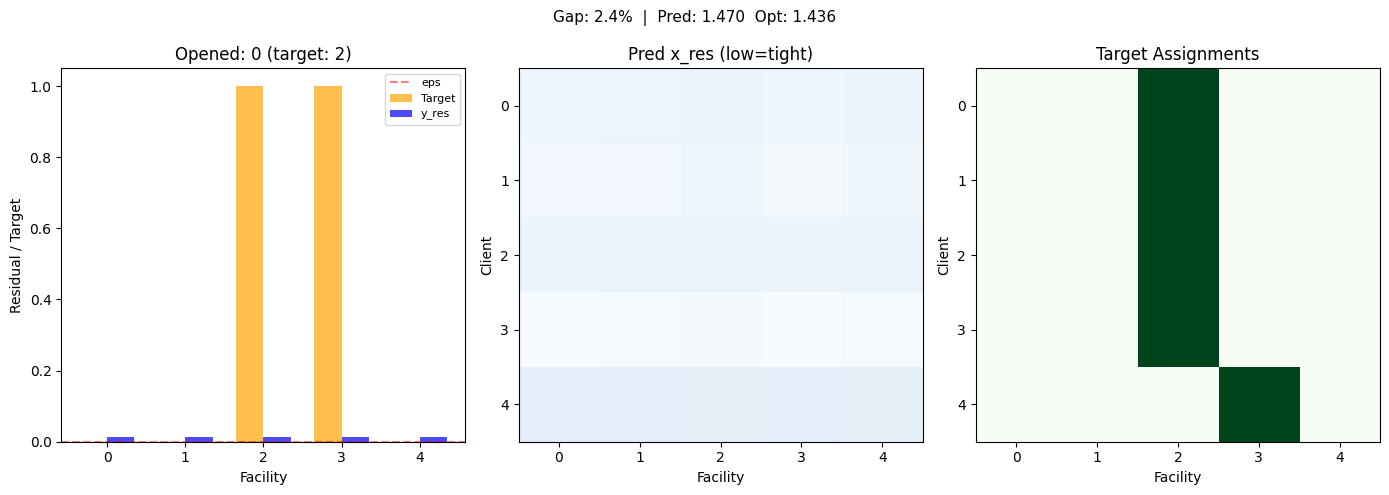

  Gap: 8.87%  Pred: 2.7770  Opt: 2.5508


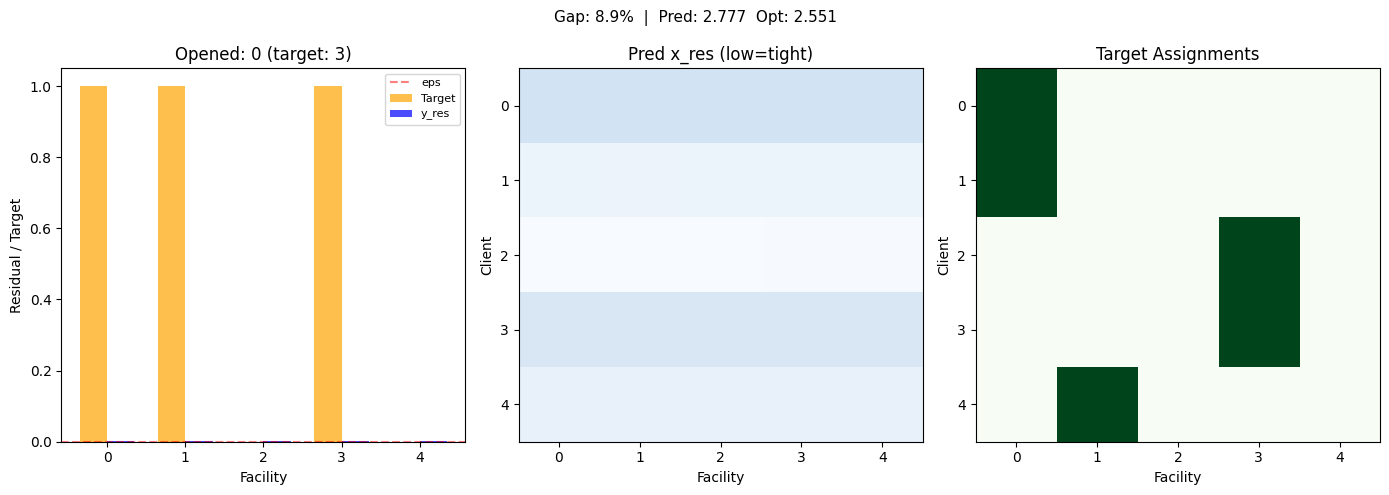

  Gap: 15.03%  Pred: 1.5875  Opt: 1.3801


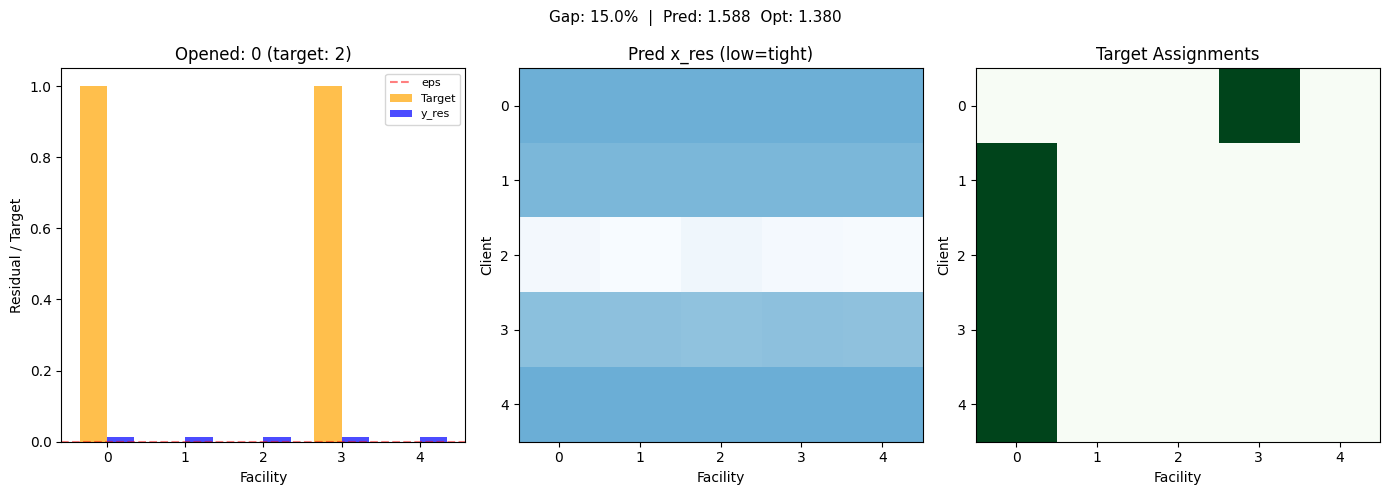

WORST predictions
  Gap: 538.91%  Pred: 8.8749  Opt: 1.3891


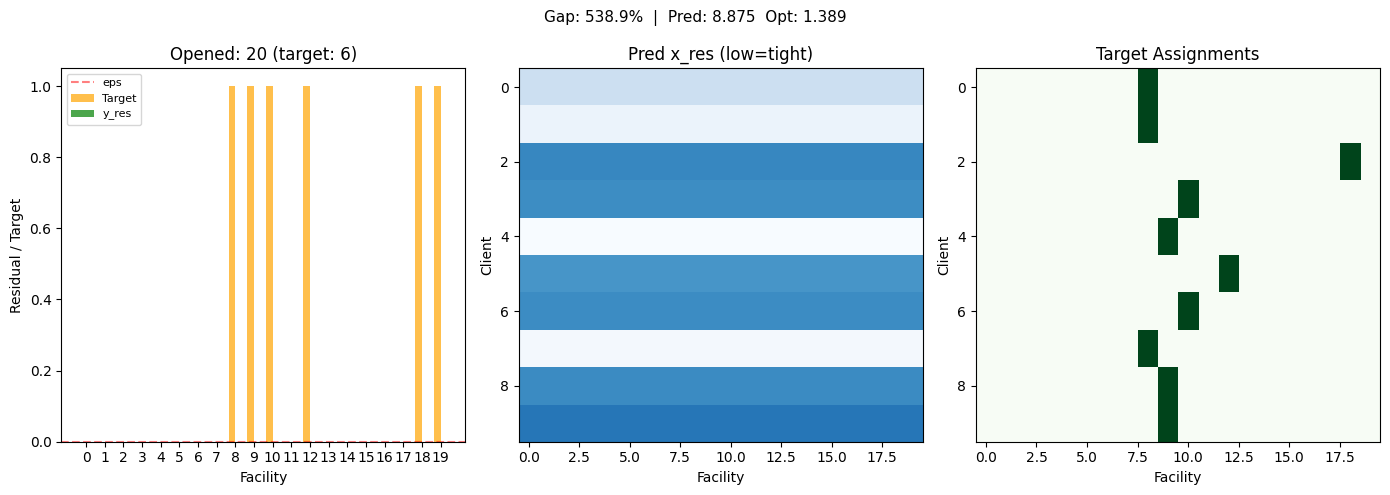

  Gap: 543.22%  Pred: 10.8112  Opt: 1.6808


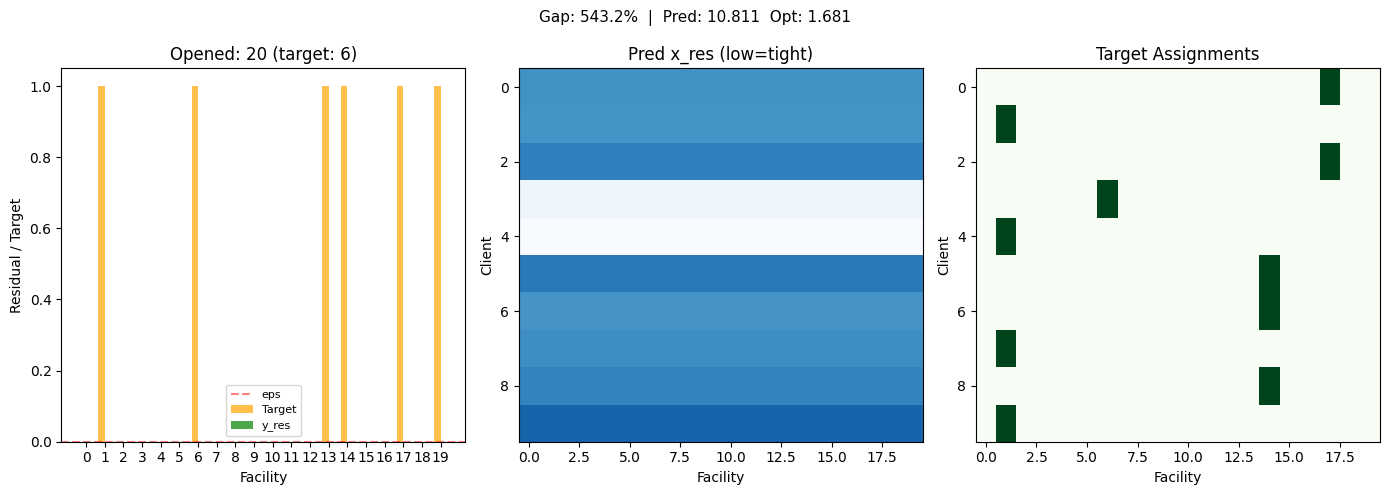

  Gap: 592.62%  Pred: 12.7066  Opt: 1.8346


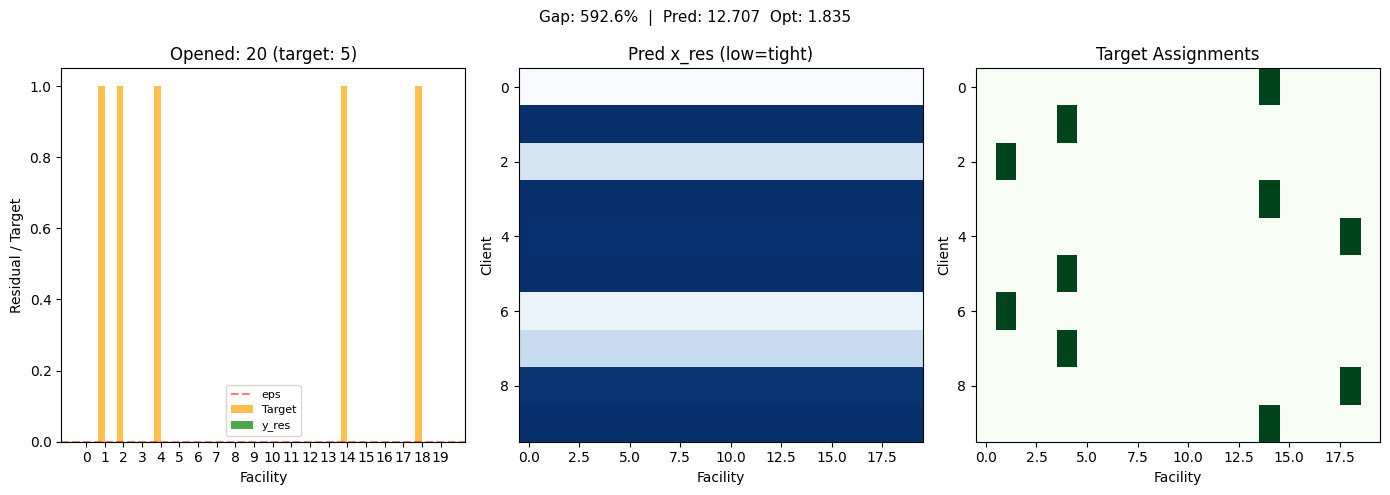

In [8]:
# ── Inspect best and worst ────────────────────────────────────────────────────
def inspect_solution(r, n_fac, n_cli, figsize=(14, 5)):
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Facility residuals vs target
    ax = axes[0]
    x_pos = np.arange(n_fac); w = 0.35
    ax.bar(x_pos - w/2, r["y_target"][:n_fac], w, label="Target", alpha=.7, color="orange")
    colors = ["green" if o else "blue" for o in r["opened"][:n_fac]]
    ax.bar(x_pos + w/2, r["y_res"][:n_fac], w, label="y_res", alpha=.7, color=colors)
    ax.axhline(1e-8, color="r", ls="--", alpha=.5, label="eps")
    ax.set(xlabel="Facility", ylabel="Residual / Target")
    ax.set_title(f"Opened: {int(r['opened'].sum())} (target: {int((r['y_target']>.5).sum())})")
    ax.legend(fontsize=8); ax.set_xticks(x_pos)

    # x_res heatmap
    axes[1].imshow(r["x_res"].reshape(n_cli, n_fac), aspect="auto", cmap="Blues_r", vmin=0)
    axes[1].set(xlabel="Facility", ylabel="Client", title="Pred x_res (low=tight)")

    # Target assignments
    axes[2].imshow(r["x_target"].reshape(n_cli, n_fac), aspect="auto", cmap="Greens", vmin=0, vmax=1)
    axes[2].set(xlabel="Facility", ylabel="Client", title="Target Assignments")

    gap = (r["opt_ratio"] - 1) * 100
    fig.suptitle(f"Gap: {gap:.1f}%  |  Pred: {r['pred_cost']:.3f}  Opt: {r['optimum']:.3f}", fontsize=11)
    plt.tight_layout(); plt.show()

N_INSPECT = 3
sorted_results = sorted(all_results, key=lambda r: r["opt_ratio"])

print("=" * 60, "\nBEST predictions\n", "=" * 60)
for r in sorted_results[:N_INSPECT]:
    print(f"  Gap: {(r['opt_ratio']-1)*100:.2f}%  Pred: {r['pred_cost']:.4f}  Opt: {r['optimum']:.4f}")
    inspect_solution(r, r["n_fac"], r["n_cli"])

print("=" * 60, "\nWORST predictions\n", "=" * 60)
for r in sorted_results[-N_INSPECT:]:
    print(f"  Gap: {(r['opt_ratio']-1)*100:.2f}%  Pred: {r['pred_cost']:.4f}  Opt: {r['optimum']:.4f}")
    inspect_solution(r, r["n_fac"], r["n_cli"])

In [9]:
dataset[0]["x"].x[:, 6, :].view(10,10)

tensor([[ 2.0629e-01,  1.2594e-01,  1.2646e-01, -1.4805e-01,  5.2510e-01,
          1.8829e-01,  5.8232e-01, -1.8917e-02, -1.7364e-02,  2.9724e-01],
        [ 2.3333e-01,  3.7637e-01,  3.0009e-01,  3.0779e-01,  8.4965e-01,
         -3.1185e-01,  4.8545e-01,  3.3944e-01, -2.1486e-02,  2.8360e-01],
        [-5.2871e-03, -5.2103e-02,  1.7110e-01,  2.6080e-02, -6.8130e-04,
          1.2128e-01,  6.1132e-02, -1.5423e-02,  1.1526e-01,  3.5894e-03],
        [ 5.0416e-01,  5.5404e-01,  6.3606e-02,  2.8347e-01,  1.1692e+00,
         -4.8970e-02,  9.6305e-01,  4.1394e-01, -2.7532e-01,  6.1141e-01],
        [ 1.0026e-01,  1.6728e-01,  7.7530e-01,  4.0682e-01,  9.2875e-02,
          4.5462e-01, -1.3824e-01,  2.9244e-01,  5.5995e-01,  3.5221e-02],
        [-5.4546e-02, -2.5605e-01,  2.6736e-01, -2.0122e-01, -1.3505e-01,
          2.6007e-01,  2.1191e-01, -2.8126e-01,  1.5728e-01, -1.3488e-03],
        [ 1.5384e-01,  3.5836e-02,  2.0329e-01, -2.5623e-01,  4.0206e-01,
          2.4329e-01,  5.1651e-0